In [25]:
include("MiniCollectiveSpins.jl")
include("Functions_time_evol_boxes.jl")
using PyPlot
using Statistics
using JLD2
using OrdinaryDiffEq

### Define the system

In [26]:
# Parameters
N_list = [10;]
r = 10
sat = [1:10:65;]
n0 = 1279

# Constants
d0_lb = 5e-10 # Minimum distance between the atoms (lower boundary) in m
λ = 421e-9
γ = 32.7e6 # In Hz
N = N_list[1]

# Rabi frequency
Ω_RO = γ.*sqrt.(sat/2)

# Quantization axis along z
e = [0, 0, 1.]

# Normalisation
d0_lb = d0_lb / λ
Ω_RO = Ω_RO / γ
γ = 1.

t_end = 1e2

window_t, window_var = 2, 4
threshold_box = 1e-5; # Time over which the boxes are computed

# Plots of the time evolution

0.0%┣                                                ┫ 0/7 [00:00<00:00, -0s/it]
14.3%┣██████▏                                    ┫ 1/7 [00:00<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████████┫ 7/7 [00:00<00:00, 63it/s]
100.0%┣██████████████████████████████████████████████┫ 7/7 [00:00<00:00, 62it/s]


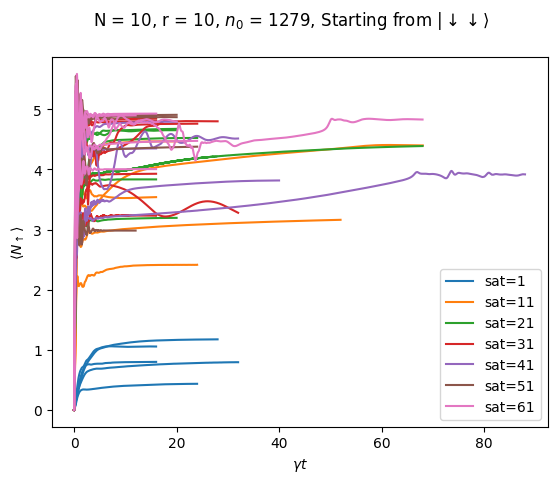

In [27]:
close("all")
fig, ax = subplots()
list_t_N, popup_t_N, nbr_error_t_N, sol_t_N = [], [], [], []

for (i, s) in ProgressBar(enumerate(sat))
    line = []
    @load "solutions/sol_N_$(N)_r_$(r)_sat_$(s)_n0_$n0.jld2" sol_tasks
    list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N, list_t), push!(popup_t_N, popup_t), push!(nbr_error_t_N, nbr_error), push!(sol_t_N, sol_t)
    for j in 1:length(popup_t)
        if j ∉ nbr_error
            if line == []
                line, = ax.plot(list_t[j], popup_t[j], label="sat=$(s)") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t[j], popup_t[j], color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  N_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

0.0%┣                                                ┫ 0/7 [00:00<00:00, -0s/it]
100.0%┣█████████████████████████████████████████████┫ 7/7 [00:00<00:00, 235it/s]
100.0%┣█████████████████████████████████████████████┫ 7/7 [00:00<00:00, 227it/s]


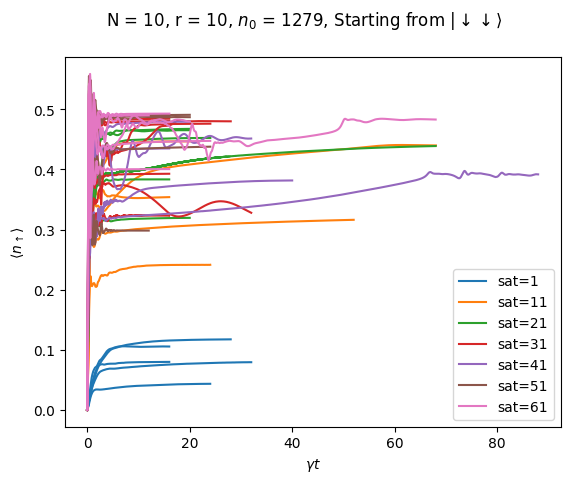

In [28]:
close("all")
fig, ax = subplots()

for (i, s) in ProgressBar(enumerate(sat))
    line = []
    for j in 1:10#length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, label="sat=$(s)") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

# Mean of the SS

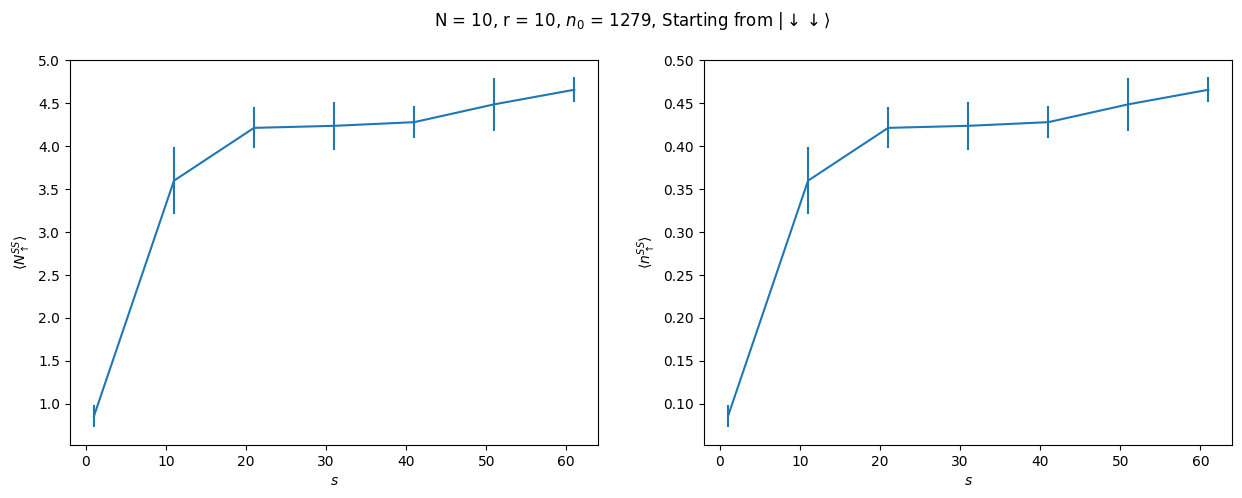

In [29]:
# For sat = 0, only throws errors as density to close from 0 --> remove the errors 
if 0 ∈ sat
    idx = findall(sat .== 0)[1]
    for i in 1:length(nbr_error_t_N[idx])
        if maximum(abs.(popup_t_N[idx][nbr_error_t_N[idx][i]])) < 10
            nbr_error_t_N[idx][i] = 0 # Physical solution
        end
    end
end

mean_SS = mean.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i]) if j ∉ nbr_error_t_N[i]] for i = 1:length(popup_t_N)])
std_SS = std.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i]) if j∉nbr_error_t_N[i]] for i = 1:length(popup_t_N)])

fig, axes = subplots(1, 2, figsize = (15, 5))
axes[1].errorbar(sat, mean_SS, yerr=std_SS ./ sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(sat)]))
axes[1].set_xlabel(L"s")
axes[1].set_ylabel(L"$\langle  N_{\uparrow}^{SS} \rangle $")

axes[2].errorbar(sat, mean_SS./N, yerr=std_SS ./ (N .* sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(sat)])))
axes[2].set_xlabel(L"s")
axes[2].set_ylabel(L"$\langle  n_{\uparrow}^{SS} \rangle $")

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")

pygui(false); gcf();
# pygui(true); show()

# Compute the total intensity (laser + $\gamma_{Gamma}/N$)

In [30]:
Itot = zeros(ComplexF64, (length(sat), r))

for (i, s) in enumerate(sat)
    @load "op_list/op_list_$N.jdl2" op_list

    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            @load "r0/r0_N_$(N)_r_$j.jdl2" r0 L
            system = SpinCollection(r0, e, gammas=1.)
            Γ_CS = GammaMatrix(system)
            
            if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
                sol_SS = sol_t_N[i][j][end]
            else
                sol_SS = sol_t_N[i][j] # Only the SS was saved
            end

            for a = 1:N
                for b = 1:N
                    if a == b
                        Itot[i, j] += Γ_CS[a, a]*sol_SS[a]
                    end
                    if b > a
                        corr = [22*10^(floor(Int, log10(a))+1)+a, 22*10^(floor(Int, log10(b))+1)+b]
                        try
                            Itot[i, j] += 2*Γ_CS[a, b]*sol_SS[findall(x->x==corr || x==reverse(corr), op_list)[1]]
                        catch
                            println("Error @ $N, r=$j, a=$a, b=$b, corr=$corr")
                        end
                    end
                end
            end
            Itot[i, j] /= N
        end
    end
end
Itot

7×10 Matrix{ComplexF64}:
 0.127819+3.93083e-20im  0.213179-4.44642e-19im  …  0.113961-1.72786e-18im
  1.96512+2.0239e-17im        0.0+0.0im                  0.0+0.0im
  2.11633+6.9147e-18im        0.0+0.0im                  0.0+0.0im
  2.29898-2.07967e-18im   1.16045+2.85877e-17im      1.10999-3.30192e-18im
  1.45959-4.98332e-17im       0.0+0.0im                  0.0+0.0im
      0.0+0.0im           2.42632+4.12042e-18im  …   0.97092-5.08665e-19im
  2.37403-1.04416e-17im       0.0+0.0im              1.62374-2.15672e-17im

In [31]:
Itot = real.(Itot)

7×10 Matrix{Float64}:
 0.127819  0.213179  0.149832  0.0      …  0.0698611  0.0      0.113961
 1.96512   0.0       0.0       1.90175     0.704404   0.0      0.0
 2.11633   0.0       0.0       1.46574     1.99504    2.17916  0.0
 2.29898   1.16045   0.0       1.57126     2.30758    0.0      1.10999
 1.45959   0.0       0.0       0.0         2.02411    2.04202  0.0
 0.0       2.42632   2.30253   0.0      …  2.03408    2.40903  0.97092
 2.37403   0.0       2.23643   2.39425     0.0        2.28606  1.62374

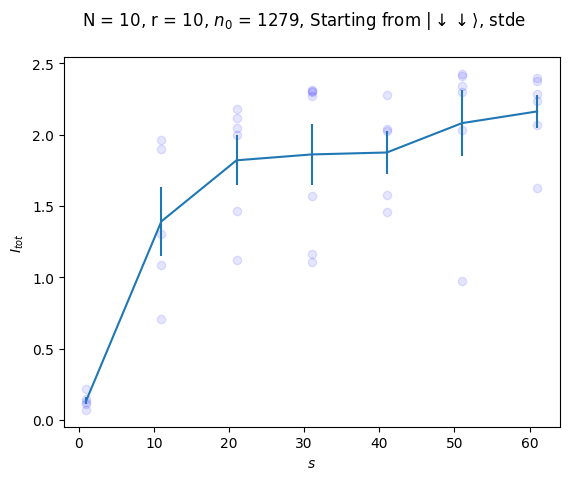

In [32]:
close("all")
fig = subplots()

errorbar(sat, [mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(sat)])

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], Itot[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"$I_{tot}$")

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $, stde")

# pygui(true); show()
pygui(false);

In [33]:
@save "Itot/Itot_N_$(N)_r_$(r)_sat_$(sat)_n0_$n0.jdl2" Itot nbr_error_t_N sat